# Biased training sets

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/biprateep/lazy-tfm/blob/tutorials/distribution_shift.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-181717?logo=github)](https://github.com/biprateep/lazy-tfm/blob/tutorials/distribution_shift.ipynb)

A tabular foundation model answers from its context, so its distributions
can only be as good as the context is representative of the rows we ask
about. In this tutorial, we predict the house values of northern
California from a context of southern districts only, and compare the
scores with those from a context drawn like the test set. We then add a
few hundred representative rows to the biased context, which is the main
remedy we found in our own tests, and compare TabPFN-3.5 with LimiX-2 on
the biased context.

## Setup

On Google Colab, the cell below installs the package with the TabPFN
backend and the dependencies of LimiX. Elsewhere, install it first with
`pip install 'lazy-tfm[tabpfn,limix]'`. The code of LimiX itself is not on
PyPI and is installed separately (see
[Installation](https://lazy-tfm.readthedocs.io/en/latest/installation.html)).
Without it, the comparison with LimiX-2 at the end is skipped, and
everything else runs.

In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install -q 'lazy-tfm[tabpfn,limix]'
    pass

In [2]:
import matplotlib.pyplot as plt  # Plotting
import numpy as np  # Arrays
import pandas as pd  # Tables

import lazy
from lazy import datasets
from lazy import metrics
from lazy import plotting

SEED = 299792458  # One seed for everything random

plotting.use_style()
plt.rcParams["figure.dpi"] = 110  # Readable in a notebook

## A geographic selection

`load_dataset("california_housing")` gives the median house value of
20,640 census block groups (districts) of California from the 1990 census,
with eight features that include the latitude and longitude of each
district (see
[Demo datasets](https://lazy-tfm.readthedocs.io/en/latest/guide/datasets.html)).
We express the values in units of 100,000 USD. Since the census capped the
values at 500,001 USD, the capped districts carry a lower bound rather than
a value, and we drop them.

We then split the state at a latitude of 36°N. The districts south of it
(Los Angeles and San Diego among them) are the only ones we label, and we
predict the districts north of it (the Bay Area, Sacramento and the north
of the state). This mimics a survey whose labeled objects come from one
part of the population only.

In [3]:
data = datasets.load_dataset("california_housing")
uncapped = data.y < 500_000
X = data.X[uncapped].reset_index(drop=True)
y = data.y[uncapped] / 1e5  # [100,000 USD]

south = np.flatnonzero(X["latitude"] < 36.0)
north = np.flatnonzero(X["latitude"] >= 36.0)
print(f"{len(X):,} districts: {len(south):,} south, {len(north):,} north")

19,648 districts: 11,182 south, 8,466 north


To keep the tutorial quick, we use contexts of 3,000 districts and score
on 1,500 northern districts. We draw four disjoint sets at random: the test
set and a pool of 1,000 calibration districts from the north, a
representative context of 3,000 other northern districts, and a biased
context of 3,000 southern districts. The representative context is the
"random split", drawn exactly like the test set.

In [4]:
rng = np.random.default_rng(SEED)
north = rng.permutation(north)
test, calibration, representative = np.split(north[:5_500], [1_500, 2_500])
biased = rng.choice(south, size=3_000, replace=False)

X_test, y_test = X.iloc[test], y[test]

The figure below shows where the districts of each set lie (left) and the
distribution of their house values (right).

biased context (south): 13% below 100,000 USD
representative context: 26% below 100,000 USD
test (north): 27% below 100,000 USD


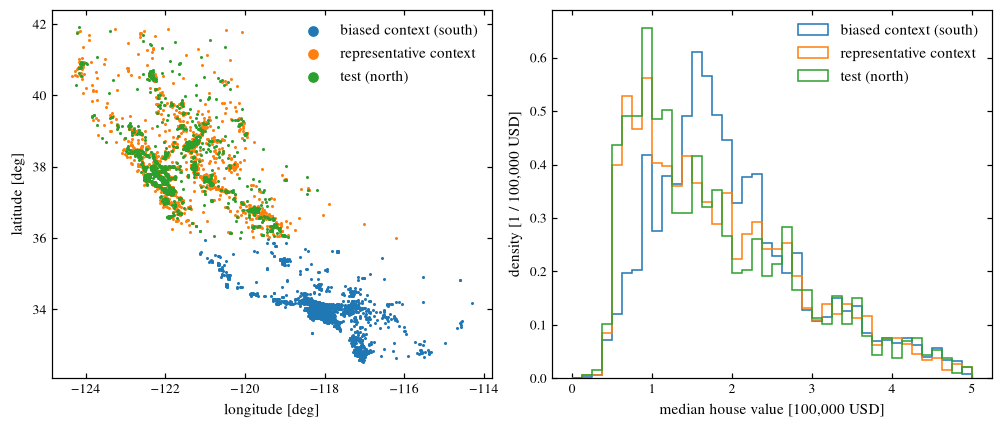

In [5]:
fig, (ax_map, ax_hist) = plt.subplots(
    1, 2, figsize=(9, 3.8), layout="constrained"
)
sets = {
    "biased context (south)": biased,
    "representative context": representative,
    "test (north)": test,
}
bins = np.linspace(0, 5, 41)
for label, idx in sets.items():
    ax_map.scatter(
        X["longitude"].iloc[idx], X["latitude"].iloc[idx], s=1, label=label
    )
    ax_hist.hist(y[idx], bins=bins, density=True, histtype="step", label=label)
    print(f"{label}: {np.mean(y[idx] < 1):.0%} below 100,000 USD")
ax_map.set_xlabel("longitude [deg]")
ax_map.set_ylabel("latitude [deg]")
ax_map.legend(markerscale=6, loc="upper right")
ax_hist.set_xlabel("median house value [100,000 USD]")
ax_hist.set_ylabel("density [1 / 100,000 USD]")
ax_hist.legend()

The left panel shows that the biased context and the test set cover
different parts of the state, while the representative context covers the
same part as the test set. The right panel shows that their values are
also distributed differently. Only 13% of the southern districts are
cheaper than 100,000 USD, compared with 27% of the test set, which has its
peak below that value. Since the latitude of every test district is
outside the range of the biased context, the model has to extrapolate in
that feature as well (see
[Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html)).

## Scores on a representative and a biased context

We score the densities of each model on a grid of 220 bins over
$0 \le y \le 5.5$ (in units of 100,000 USD), which covers every value. The
function below returns the table of `metrics.summarize` with one more
column, the fraction of test districts whose value falls inside the
central 68% interval of its density, which we compute from the PIT (i.e.,
the value of the predicted CDF at the true value). We report the **CRPS**
(continuous ranked probability score, in the units of the target; lower is
better), the 68% **coverage** (68% for calibrated densities), the
Kolmogorov-Smirnov distance of the PIT from a uniform distribution (zero
for calibrated densities), and the **bias**, the median offset of the mode
from the true value (see
[From model output to distribution](https://lazy-tfm.readthedocs.io/en/latest/guide/distributions.html)).

In [6]:
GRID = lazy.Grid.from_edges(np.linspace(0.0, 5.5, 221))
COLUMNS = ["crps", "coverage_68", "pit_ks", "bias"]


def score(
    model: lazy.BaseDensityRegressor, label: str
) -> tuple[pd.DataFrame, np.ndarray]:
    """Scores a fitted model on the test set; returns (table, pit)."""
    pdfs = model.predict_proba(X_test, GRID)
    table = metrics.summarize(y_test, GRID, pdfs, label=label)
    _, pit = metrics.per_object_scores(y_test, GRID, pdfs)
    table["coverage_68"] = np.mean(np.abs(pit - 0.5) <= 0.34)
    return table, pit

We fit TabPFN-3.5 on the representative context, on the biased context,
and on the biased context with 300 of the calibration districts added (the
remedy, discussed below), and score each on the same test set.

In [7]:
contexts = {
    "representative": representative,
    "biased": biased,
    "biased + 300": np.concatenate([biased, calibration[:300]]),
}
tables, pits = [], {}
for label, idx in contexts.items():
    model = lazy.LazyModel(random_state=SEED).fit(X.iloc[idx], y[idx])
    table, pits[label] = score(model, label)
    tables.append(table)

pd.concat(tables).set_index("model")[COLUMNS].round(3)

,crps,coverage_68,pit_ks,bias
model,,,,
representative,0.159,0.669,0.029,-0.024
biased,0.539,0.432,0.489,-0.682
biased + 300,0.206,0.673,0.039,-0.016


With the representative context, the densities are close to calibrated,
with a 68% coverage of 66.9%, a PIT KS distance of 0.029 and a CRPS of
0.159. With the biased context, the CRPS is more than three times as large
(0.539), the 68% interval holds the true value for only 43.2% of the
districts, and the median mode is lower than the truth by 0.682 (68,200
USD). Adding 300 northern districts to the biased context (i.e., 9% of its
3,300 rows) brings the coverage to 67.3%, the KS distance to 0.039 and the
bias to -0.016. However, its CRPS of 0.206 is still about 30% above that of
the representative context. We see the same in the PIT distributions
below.

Median PIT on the biased context: 0.87


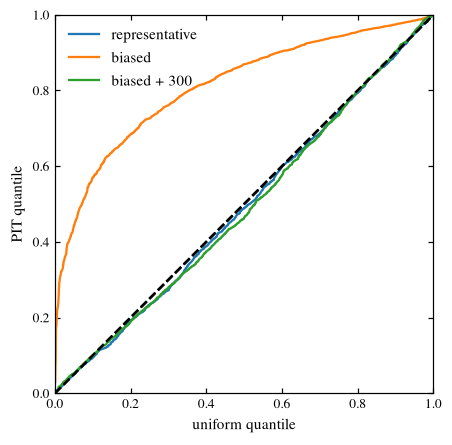

In [8]:
fig, ax = plt.subplots(figsize=(4, 4), layout="constrained")
for label, pit in pits.items():
    plotting.plot_pit_qq(pit, ax=ax, label=label, lw=1.5)
ax.legend(loc="upper left")
print(f"Median PIT on the biased context: {np.median(pits['biased']):.2f}")

The figure shows the quantiles of the PIT values of the test districts
against those of a uniform distribution, which lie on the diagonal for
calibrated densities. The curves of the representative context and of the
biased context with 300 calibration districts follow the diagonal closely.
The curve of the biased context lies far above it, with half of the PIT
values above 0.87, which means that the true value sits in the upper tail
of the density for many districts. We suspect this is because the model
extrapolates the dependence of the value on location from the south, where
it is not the same as in the north.

## How large a calibration sample

To see how many representative rows the context needs, we add the first
30, 100, 300 and 1,000 districts of the calibration pool to the biased
context and score each on the same test set. The rows with 0 and 300
calibration districts were already scored above.

In [9]:
sizes = [0, 30, 100, 300, 1_000]
done = {0: tables[1], 300: tables[2]}  # Already scored above
sweep = []
for n_cal in sizes:
    if n_cal not in done:
        idx = np.concatenate([biased, calibration[:n_cal]])
        model = lazy.LazyModel(random_state=SEED).fit(X.iloc[idx], y[idx])
        done[n_cal], _ = score(model, f"biased + {n_cal}")
    sweep.append(done[n_cal].assign(model=f"biased + {n_cal}"))
sweep = pd.concat(sweep).set_index("model")[COLUMNS]
sweep.round(3)

,crps,coverage_68,pit_ks,bias
model,,,,
biased + 0,0.539,0.432,0.489,-0.682
biased + 30,0.255,0.669,0.104,-0.139
biased + 100,0.231,0.662,0.050,-0.056
biased + 300,0.206,0.673,0.039,-0.016
biased + 1000,0.174,0.671,0.022,-0.030


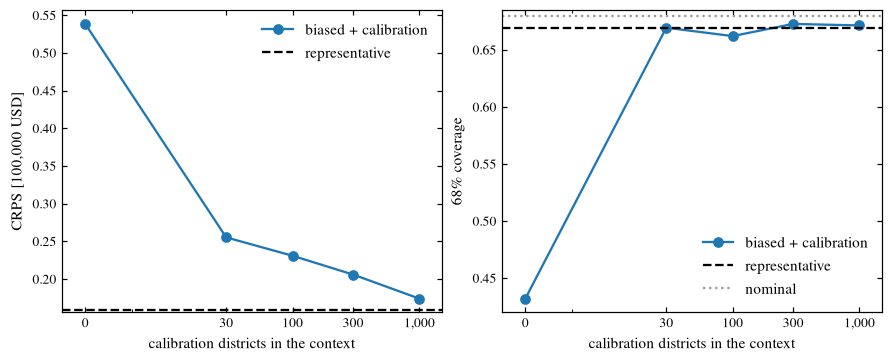

In [10]:
reference = tables[0].iloc[0]
fig, (ax_crps, ax_cov) = plt.subplots(
    1, 2, figsize=(8, 3.2), layout="constrained"
)
for ax, column, name in [
    (ax_crps, "crps", "CRPS [100,000 USD]"),
    (ax_cov, "coverage_68", "68% coverage"),
]:
    ax.plot(sizes, sweep[column], "o-", label="biased + calibration")
    ax.axhline(reference[column], color="k", ls="--", label="representative")
    ax.set_xscale("symlog", linthresh=30)
    ax.set_xlim(-5, 1_500)
    ax.set_xticks(sizes, [f"{n:,}" for n in sizes])
    ax.set_xlabel("calibration districts in the context")
    ax.set_ylabel(name)
ax_cov.axhline(0.68, color="0.6", ls=":", label="nominal")
ax_crps.legend()
ax_cov.legend()

The figure shows the CRPS (left) and the 68% coverage (right) against the
number of calibration districts in the context, on a scale that is linear
below 30 and logarithmic above it, with the representative context as the
dashed line. We see that most of the gain comes from the first 30
districts (1% of the context), which lower the CRPS from 0.539 to 0.255
and bring the coverage from 43.2% to 66.9%. The rest of the PIT takes
longer to recover, with a KS distance of 0.104 and a bias of -0.139 at 30
districts, which fall to 0.039 and -0.016 at 300. More districts keep
lowering the CRPS, to 0.174 with 1,000, which is still above the 0.159 of
the representative context. Therefore, a calibration sample of a few
hundred rows drawn like the test set repairs the calibration of the
densities on this split, and a larger one also makes them sharper.

## LimiX-2 on the biased context

In our own tests on photometric redshifts, LimiX-2 handled biased training
sets best of the models in `lazy` (see
[Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html)).
We therefore fit LimiX-2 on the biased context, with and without the 300
calibration districts, and compare it with TabPFN-3.5 on the same test
set. If the code of LimiX is not installed, the cell prints a message and
skips the comparison.

In [11]:
try:
    rows = []
    for label in ["biased", "biased + 300"]:
        idx = contexts[label]
        limix = lazy.LazyModel("limix", random_state=SEED)
        limix.fit(X.iloc[idx], y[idx])
        table, _ = score(limix, f"LimiX-2, {label}")
        rows.append(table)
except ImportError as error:
    print(f"Skipping LimiX-2, whose code is not installed:\n{error}")
    comparison = None
else:
    for table, label in zip(tables[1:], ["biased", "biased + 300"]):
        rows.append(table.assign(model=f"TabPFN-3.5, {label}"))
    comparison = pd.concat(rows).set_index("model")[COLUMNS].sort_index()
    comparison = comparison.round(3)
comparison

,crps,coverage_68,pit_ks,bias
model,,,,
"LimiX-2, biased",0.498,0.614,0.433,-0.794
"LimiX-2, biased + 300",0.202,0.651,0.031,-0.025
"TabPFN-3.5, biased",0.539,0.432,0.489,-0.682
"TabPFN-3.5, biased + 300",0.206,0.673,0.039,-0.016


On the biased context alone, LimiX-2 has a lower CRPS than TabPFN-3.5
(0.498 vs. 0.539) and a 68% coverage closer to nominal (61.4% vs. 43.2%).
However, its bias is larger (-0.794 vs. -0.682), and its CRPS is still
about three times that of the representative context, so neither model
recovers from the selection on its own. With 300 calibration districts,
the two models are very similar (a CRPS of 0.202 vs. 0.206, and a coverage
of 65.1% vs. 67.3%). Therefore, on this dataset, LimiX-2 is the better of
the two on a biased context only by a small margin in CRPS, and the
calibration sample matters far more than the choice of model. This is one
split of one dataset with one seed, which is not enough to confirm or rule
out the finding of our own tests.

## Next steps

The same experiment for photometric redshifts, with the spectroscopically
selected training set of `lazy.datasets.fetch_dc1_biased` and its
representative calibration sample, is in the
[photometric redshifts](https://lazy-tfm.readthedocs.io/en/latest/tutorials/photo_z.html)
tutorial. We subsampled the contexts and the test set to keep this
tutorial quick, and the full-size run (all 11,182 southern districts in the
context) needs only larger index arrays. For more, we suggest the following
pages:

- [Limits and pitfalls](https://lazy-tfm.readthedocs.io/en/latest/guide/limits.html):
  biased training sets, extrapolation and other cases in which the answer
  should not be taken at face value.
- [Choosing a model](https://lazy-tfm.readthedocs.io/en/latest/guide/choosing.html):
  which model to choose, including for a biased training set.